# Methodology Plots: Time Series Profiles and Cross-Validation Scheme

### Notebook Objective

This notebook produces figures for the methodology section of the thesis.
It does NOT depend on the experiment results (`results_comparative.csv`) — all
plots are derived from deterministic generators and the cross-validation
configuration, so it can be run at any time independently of the main pipeline
(including while the experiment loop is still running).

### Contents
1. **Integrity check** — MD5 hashes confirm that the series used here are
   bit-identical to those processed by the main experiment loop.
2. **Raw time series** — six profiles, full 2000 points each, with the CV pool
   / held-out test boundary marked.
3. **Value distributions** — histogram per profile.
4. **Autocorrelation structure** — ACF and PACF per profile, motivating the
   `window_size` grid in the experiment.
5. **Cross-validation scheme** — diagram of the sliding-window K=5 CV layout.


In [2]:
# === IMPORTS AND SETUP ===
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import hashlib

from src.data_generation import mackey_glass, generate_arma_data, generate_narma_data
from src.experiment import sliding_cv_folds, WASHOUT

try:
    from statsmodels.tsa.stattools import acf, pacf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not installed — ACF/PACF cells will be skipped. "
          "Install with: pip install statsmodels")

# Auto-reload custom modules
%load_ext autoreload
%autoreload 2

print("Libraries and modules loaded successfully.")


Libraries and modules loaded successfully.


In [3]:
# === GENERATE THE SIX TIME SERIES ===
# These calls match the experiment loop EXACTLY: same generators, same params,
# same default seeds inside data_generation.py — so the series are bit-identical
# to those the QRC and Classical ESN models see during the main pipeline.

PROFILES = [
    ('Mackey-Glass (tau=17)',  mackey_glass(tau=17)),
    ('Mackey-Glass (tau=30)',  mackey_glass(tau=30)),
    ('Mackey-Glass (tau=100)', mackey_glass(tau=100)),
    ('ARMA(1,2)',              generate_arma_data()),
    ('NARMA-10',               generate_narma_data(order=10)),
    ('NARMA-5',                generate_narma_data(order=5)),
]

# Constants from the experiment notebook
TRAIN_FRACTION = 0.8
N_SPLITS = 5
N_TOTAL = len(PROFILES[0][1])
CV_END = int(N_TOTAL * TRAIN_FRACTION)

# Ensure output directory exists
FIGURES_DIR = '../reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Generated {len(PROFILES)} time series, {N_TOTAL} points each.")
print(f"CV pool: indices [0, {CV_END})  |  Held-out test: indices [{CV_END}, {N_TOTAL})")


Generated 6 time series, 2000 points each.
CV pool: indices [0, 1600)  |  Held-out test: indices [1600, 2000)


## 1. Integrity check

MD5 hashes (first 12 hex characters) of every generated series. These should
stay stable across runs and machines because:

- `mackey_glass` is purely deterministic — no RNG, only an ODE integration
  with a hard-coded initial condition.
- `generate_arma_data` and `generate_narma_data` seed `np.random.seed(42)`
  internally as part of their default arguments, so calling them with the same
  parameters always returns the same sequence.

If a hash here differs from a hash computed inside the experiment loop, it
means something in the generator code or its dependencies has changed.


In [4]:
def md5_array(arr):
    return hashlib.md5(np.ascontiguousarray(arr).tobytes()).hexdigest()[:12]


print(f"{'Profile':28s}  {'Length':>6s}  {'MD5 (first 12)':14s}")
print("-" * 56)
for name, series in PROFILES:
    print(f"{name:28s}  {len(series):>6d}  {md5_array(series)}")


Profile                       Length  MD5 (first 12)
--------------------------------------------------------
Mackey-Glass (tau=17)           2000  73561151d2f3
Mackey-Glass (tau=30)           2000  f1c12357e948
Mackey-Glass (tau=100)          2000  24fe39dc51df
ARMA(1,2)                       2000  34d44fc9adbe
NARMA-10                        2000  6beaf329161b
NARMA-5                         2000  cf4d693d3f59


## 2. Raw time series

Six profiles used in the experiment, full 2000 points each, scaled to [0, 1].
The green region marks the held-out 20% test segment — never seen during
cross-validation or hyperparameter selection.


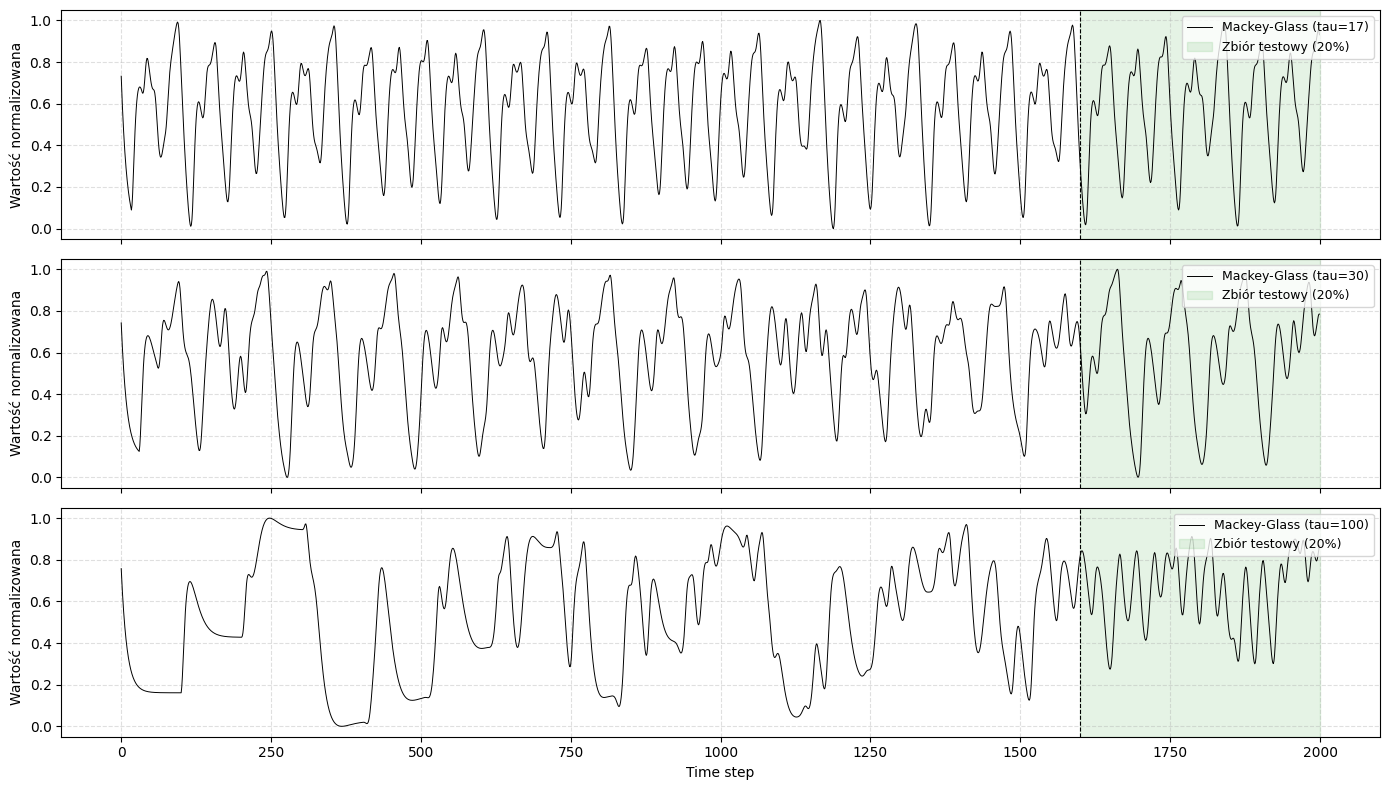

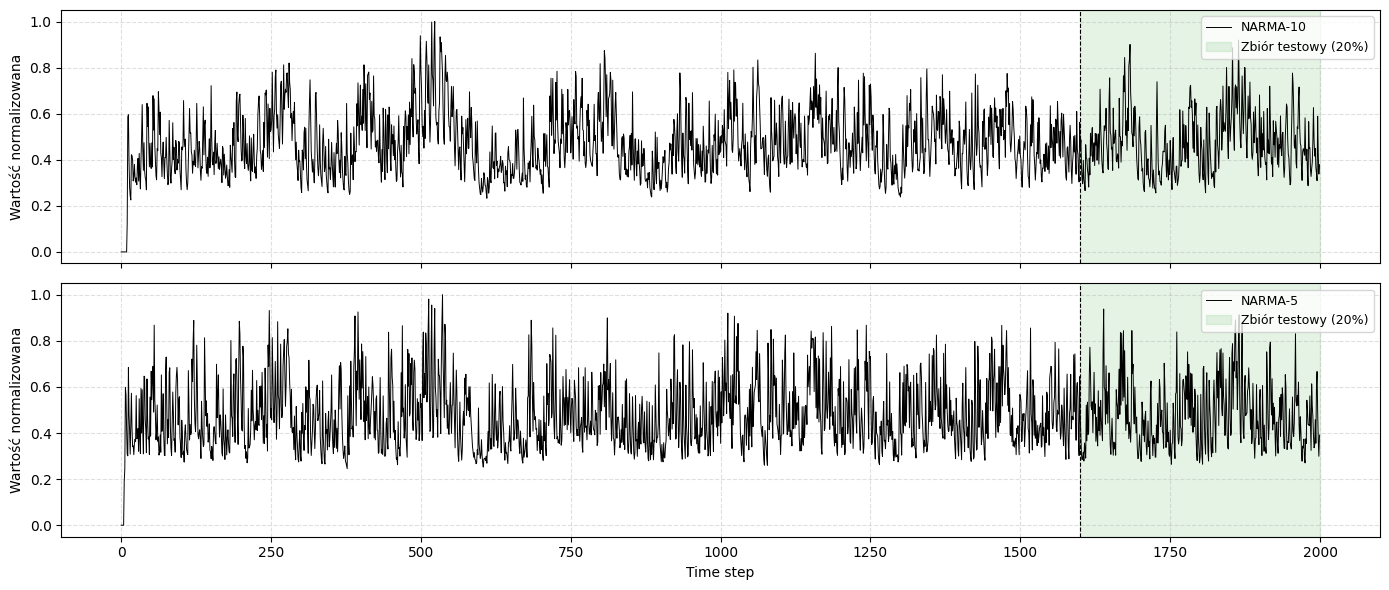

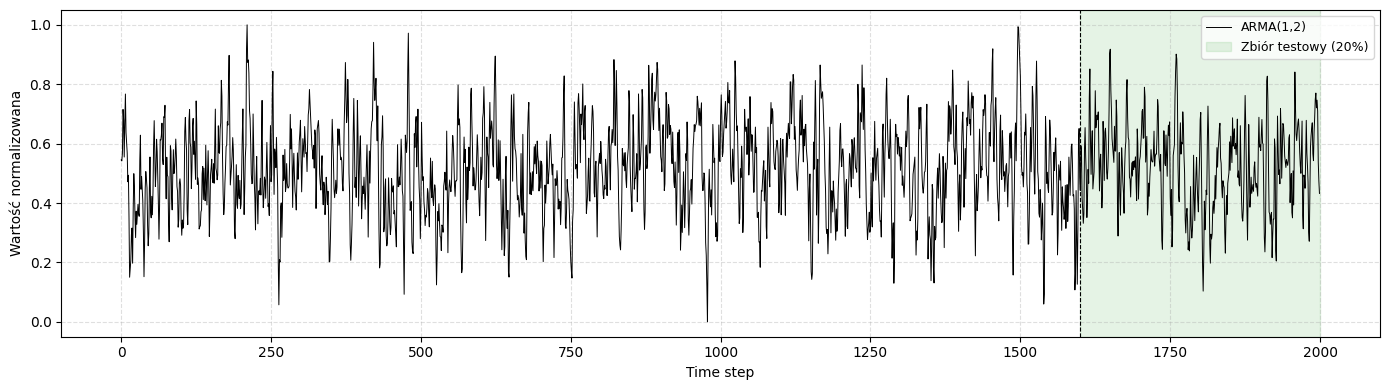

In [5]:
# --- Mackey-Glass: three panels stacked vertically ---
mg_profiles = [p for p in PROFILES if p[0].startswith('Mackey-Glass')]
fig, axes = plt.subplots(len(mg_profiles), 1, figsize=(14, 8), sharex=True)
for ax, (name, series) in zip(axes, mg_profiles):
    ax.plot(series, color='black', linewidth=0.7, label=name)
    ax.axvspan(CV_END, N_TOTAL, color='tab:green', alpha=0.12,
               label='Zbiór testowy (20%)')
    ax.axvline(CV_END, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel("Wartość normalizowana", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel("Time step", fontsize=10)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/methodology_series_mackey_glass.png',
            dpi=300, bbox_inches='tight')
plt.show()


# --- NARMA: two panels stacked vertically ---
narma_profiles = [p for p in PROFILES if p[0].startswith('NARMA')]
fig, axes = plt.subplots(len(narma_profiles), 1, figsize=(14, 6), sharex=True)
for ax, (name, series) in zip(axes, narma_profiles):
    ax.plot(series, color='black', linewidth=0.7, label=name)
    ax.axvspan(CV_END, N_TOTAL, color='tab:green', alpha=0.12,
               label='Zbiór testowy (20%)')
    ax.axvline(CV_END, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel("Wartość normalizowana", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel("Time step", fontsize=10)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/methodology_series_narma.png',
            dpi=300, bbox_inches='tight')
plt.show()


# --- ARMA: single panel ---
arma_profiles = [p for p in PROFILES if p[0].startswith('ARMA')]
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
name, series = arma_profiles[0]
ax.plot(series, color='black', linewidth=0.7, label=name)
ax.axvspan(CV_END, N_TOTAL, color='tab:green', alpha=0.12,
           label='Zbiór testowy (20%)')
ax.axvline(CV_END, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel("Wartość normalizowana", fontsize=10)
ax.set_xlabel("Time step", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/methodology_series_arma.png',
            dpi=300, bbox_inches='tight')
plt.show()


## 3. Value distributions

Histogram of values for each profile. All series are scaled to [0, 1], but
their internal distributions differ:

- Mackey-Glass concentrates around its limit-cycle attractor values.
- ARMA is roughly bell-shaped around the mean (linear filter of Gaussian noise).
- NARMA is typically right-skewed due to its multiplicative `beta*y*sum` term
  and the additive offset.

The distribution shape affects how strongly target variance can normalize
performance metrics like NMSE across profiles.


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for ax, (name, series) in zip(axes.flat, PROFILES):
    ax.hist(series, bins=50, density=True, color='tab:blue', alpha=0.6,
            edgecolor='black', linewidth=0.4)
    ax.text(0.97, 0.95, name, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.8))
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/methodology_distributions.png',
            dpi=300, bbox_inches='tight')
plt.show()


## 4. Temporal autocorrelation structure (ACF + PACF)

ACF and PACF describe how predictable each value is from its past — and they
motivate the choice of `window_size` in the experiment grid: too short a window
misses relevant lags, too long a window adds noise without new information.

- **ACF** at lag *k* measures the correlation between `y(t)` and `y(t-k)`,
  including all intermediate lags.
- **PACF** at lag *k* measures the correlation between `y(t)` and `y(t-k)`
  AFTER controlling for lags 1, 2, ..., *k-1*. High PACF at lag *k* indicates
  that lag *k* itself adds independent predictive information.

Red vertical lines on each plot mark the `window_size` grid values used in the
experiment: 1, 2, 4, 6, 8, 10. If meaningful autocorrelation extends well beyond
window_size = 10, the model relies on the leaky integrator to bridge longer
dependencies.


In [ ]:
if HAS_STATSMODELS:
    fig, axes = plt.subplots(6, 2, figsize=(14, 20))
    max_lag = 40
    window_grid = [1, 2, 4, 6, 8, 10]

    # Column headers via x-axis label of the BOTTOM row, plus an annotation on the
    # TOP row for clarity. Per-row profile name annotated on the left subplot.
    for row_idx, (name, series) in enumerate(PROFILES):
        acf_vals = acf(series, nlags=max_lag, fft=True)
        pacf_vals = pacf(series, nlags=max_lag)

        # ACF (left column)
        ax_a = axes[row_idx, 0]
        ax_a.stem(range(len(acf_vals)), acf_vals, basefmt=" ")
        ax_a.axhline(0, color='black', linewidth=0.6)
        ax_a.set_xlabel("Lag", fontsize=9)
        ax_a.set_ylabel("ACF", fontsize=9)
        ax_a.grid(True, linestyle='--', alpha=0.4)
        # Profile name annotation in upper-right corner
        ax_a.text(0.97, 0.95, name, transform=ax_a.transAxes,
                  ha='right', va='top', fontsize=10, weight='bold',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor='gray', alpha=0.85))
        for ws in window_grid:
            ax_a.axvline(ws, color='red', linewidth=0.6, alpha=0.35)

        # PACF (right column)
        ax_p = axes[row_idx, 1]
        ax_p.stem(range(len(pacf_vals)), pacf_vals, basefmt=" ")
        ax_p.axhline(0, color='black', linewidth=0.6)
        ax_p.set_xlabel("Lag", fontsize=9)
        ax_p.set_ylabel("PACF", fontsize=9)
        ax_p.grid(True, linestyle='--', alpha=0.4)
        ax_p.text(0.97, 0.95, name, transform=ax_p.transAxes,
                  ha='right', va='top', fontsize=10, weight='bold',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor='gray', alpha=0.85))
        for ws in window_grid:
            ax_p.axvline(ws, color='red', linewidth=0.6, alpha=0.35)

    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/methodology_acf_pacf.png',
                dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Skipping ACF/PACF — statsmodels not installed.")
    print("To enable, run:  pip install statsmodels")


## 5. Sliding-window cross-validation scheme

The K=5 sliding-window CV layout on the 80% CV pool (1600 of 2000 points).
Each fold has the same `train_size` and `val_size`; the window slides evenly so
the first fold's train starts at index 0 and the last fold's val ends exactly
at the CV pool boundary.

Parameters (from `src.experiment.sliding_cv_folds`):
- `val_size`   = 1600 // (5 + 1) = **266** points
- `train_size` = (5 − 1) × 266 = **1064** points
- `WASHOUT`    = **100** — the first 100 reservoir states of every train/val
  segment are discarded before regression / MSE computation, to remove
  transient burn-in dynamics.

The 20% held-out test segment (indices 1600–2000, green) is never touched
during CV — it is only used once per hyperparameter combination, in a separate
Variant-A test evaluation that re-trains on the full CV pool.


In [ ]:
# --- Compute fold layout the same way sliding_cv_folds does ---
n = CV_END  # CV pool length
val_size = n // (N_SPLITS + 1)
train_size = (N_SPLITS - 1) * val_size
max_shift = n - train_size - val_size

print(f"CV pool length: {n}")
print(f"  train_size = {train_size}")
print(f"  val_size   = {val_size}")
print(f"  max_shift  = {max_shift}")

shifts = [int(round(i * max_shift / (N_SPLITS - 1))) for i in range(N_SPLITS)]
print(f"  fold shifts: {shifts}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 5.5))

# Backgrounds: CV pool + Test
ax.axvspan(0, n, color='lightgray', alpha=0.25, label='CV pool (80%)')
ax.axvspan(n, N_TOTAL, color='tab:green', alpha=0.20, label='Held-out Test (20%)')

# Draw each fold as a horizontal bar with train / val / washout markers
COLOR_TRAIN   = 'tab:blue'
COLOR_VAL     = 'tab:orange'
COLOR_WASHOUT = 'tab:red'

for i, shift in enumerate(shifts):
    y_row = N_SPLITS - i  # top fold = fold 1
    tr_start = shift
    tr_end = shift + train_size
    val_start = tr_end
    val_end = val_start + val_size

    # train + val main bars
    ax.barh(y_row, train_size, left=tr_start, height=0.55,
            color=COLOR_TRAIN, edgecolor='black', linewidth=0.4,
            label='Train' if i == 0 else None)
    ax.barh(y_row, val_size, left=val_start, height=0.55,
            color=COLOR_VAL, edgecolor='black', linewidth=0.4,
            label='Val' if i == 0 else None)

    # washout overlays (first 100 of train and first 100 of val)
    ax.barh(y_row, WASHOUT, left=tr_start, height=0.55,
            color=COLOR_WASHOUT, alpha=0.45, edgecolor='none',
            label='Washout (first 100 of each segment)' if i == 0 else None)
    ax.barh(y_row, WASHOUT, left=val_start, height=0.55,
            color=COLOR_WASHOUT, alpha=0.45, edgecolor='none')

# CV pool / test boundary
ax.axvline(n, color='black', linewidth=1.0, linestyle='--')

# Y-axis: fold labels via tick labels (cleaner than ax.text — no clipping)
ax.set_yticks(list(range(1, N_SPLITS + 1)))
ax.set_yticklabels([f"Fold {N_SPLITS - i + 1}" for i in range(1, N_SPLITS + 1)],
                   fontsize=10, weight='bold')

ax.set_xlim(-20, N_TOTAL + 20)
ax.set_ylim(0.4, N_SPLITS + 0.9)
ax.set_xlabel("Index in time series (0 — 2000)", fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9)
ax.grid(True, axis='x', linestyle='--', alpha=0.35)

fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/methodology_cv_scheme.png',
            dpi=300, bbox_inches='tight')
plt.show()


---

### Summary of generated figures

All figures saved to `../reports/figures/`:

- `methodology_series_mackey_glass.png` — three Mackey-Glass profiles stacked
- `methodology_series_narma.png` — two NARMA profiles stacked
- `methodology_series_arma.png` — single ARMA profile
- `methodology_distributions.png` — value distributions (3×2 panel)
- `methodology_acf_pacf.png` — autocorrelation analysis
- `methodology_cv_scheme.png` — sliding-window CV diagram

These figures depend only on the deterministic data generators and the CV
configuration constants — they can be regenerated at any time without re-running
the experiment loop.
